In [1]:
import pywrdrb
import matplotlib.pyplot as plt

In [2]:
import os
# Change to your preferred directory if needed
# os.chdir(my_directory)
cwd = os.getcwd()
print(f"Current working directory: {cwd}")

Current working directory: /Users/marilynsmith/Desktop/DRB_Development/Pywr-DRB/notebooks


In [3]:
from pywrdrb.model_builder import Options
help(Options)

Help on class Options in module pywrdrb.model_builder:

class Options(builtins.object)
 |  Options(NSCENARIOS: int = 1, inflow_ensemble_indices: Optional[List[int]] = None, use_hist_NycNjDeliveries: bool = True, temperature_model: Optional[dict] = None, salinity_model: Optional[dict] = None, run_sensitivity_analysis: bool = False, sensitivity_analysis_scenarios: List[str] = <factory>, release_policy_dict: Optional[dict] = <factory>, initial_volume_frac: float = 0.8) -> None
 |  
 |  A dataclass to hold options for the ModelBuilder and it default values.
 |  
 |  Attributes
 |  ----------
 |  NSCENARIOS : int
 |      Number of scenarios to run. Default is 1.
 |  inflow_ensemble_indices : Optional[List[int]]
 |      List of indices to use for inflow ensemble scenarios. Default is None.
 |  use_hist_NycNjDeliveries : bool
 |      If True, use historical NYC/NJ deliveries as demand, else use predicted demand. 
 |      Otherwise, assume demand is equal to max allotment under FFMP. Default i

In [4]:
options = {
    "release_policy_dict": {
        "beltzvilleCombined": {"type": "PWLReservoirRelease", "id": "Best Overall"},
        "prompton": {"type": "RBFReservoirRelease", "id": "Best Overall"}
    }
}

inflow_type = 'pub_nhmv10_BC_withObsScaled'
start_date = "1983-10-01"
end_date = "2023-12-31"

mb = pywrdrb.ModelBuilder(
    start_date=start_date,
    end_date=end_date,
    inflow_type=inflow_type,
    options=options
)

mb.make_model()

model_filename = os.path.join(cwd, "model.json")

# Save the model to a JSON file
mb.write_model(model_filename)

Using release param for cannonsville: STARFITReservoirRelease (policy_id: default)
Using release param for pepacton: STARFITReservoirRelease (policy_id: default)
Using release param for neversink: STARFITReservoirRelease (policy_id: default)
Using release param for wallenpaupack: STARFITReservoirRelease (policy_id: default)
Assigning release parameter STARFITReservoirRelease_wallenpaupack to wallenpaupack
Using release param for prompton: RBFReservoirRelease (policy_id: Best Overall)
Assigning release parameter RBFReservoirRelease_prompton to prompton
Using release param for shoholaMarsh: STARFITReservoirRelease (policy_id: default)
Assigning release parameter STARFITReservoirRelease_shoholaMarsh to shoholaMarsh
Using release param for mongaupeCombined: STARFITReservoirRelease (policy_id: default)
Assigning release parameter STARFITReservoirRelease_mongaupeCombined to mongaupeCombined
Using release param for beltzvilleCombined: PWLReservoirRelease (policy_id: Best Overall)
Assigning re

In [5]:
# Load the model from the JSON file
model = pywrdrb.Model.load(model_filename)

# Attach an Output Recorder
output_filename = os.path.join(cwd,"pywrdrb_output.hdf5")
recorder = pywrdrb.OutputRecorder(model, output_filename)

# Run the model
stats = model.run()

# Check if the output file was created successfully
assert os.path.exists(output_filename), "Simulation output not found."
print(" Simulation completed and output file saved:", output_filename)

/Users/marilynsmith/Desktop/DRB_Development/drb_env/lib/python3.11/site-packages/pywr/dataframe_tools.py:127: FutureWarning: Resampling with a PeriodIndex is deprecated. Cast index to DatetimeIndex before resampling instead.
  new_df = new_df.resample(target_index.freq).agg(resample_func)


[STARFIT] Loaded parameters for wallenpaupack, policy_id = default
[RBF] Loaded parameters for prompton, policy_id = Best Overall
[STARFIT] Loaded parameters for shoholaMarsh, policy_id = default
[STARFIT] Loaded parameters for mongaupeCombined, policy_id = default
[STARFIT] Loaded parameters for modified_fewalter, policy_id = default
[STARFIT] Loaded parameters for merrillCreek, policy_id = default
[STARFIT] Loaded parameters for hopatcong, policy_id = default
[STARFIT] Loaded parameters for assunpink, policy_id = default
[STARFIT] Loaded parameters for ontelaunee, policy_id = default
[STARFIT] Loaded parameters for stillCreek, policy_id = default
[STARFIT] Loaded parameters for greenLane, policy_id = default
[STARFIT] Loaded parameters for nockamixon, policy_id = default
[STARFIT] Loaded parameters for modified_blueMarsh, policy_id = default
[PWL] Loaded parameters for beltzvilleCombined, policy_id = Best Overall


/var/folders/80/7p1ljypd56n9qsjyfk7rxqcr0000gn/T/ipykernel_97637/1763192078.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  stats = model.run()


 Simulation completed and output file saved: /Users/marilynsmith/Desktop/DRB_Development/Pywr-DRB/notebooks/pywrdrb_output.hdf5


In [9]:
# === Set path to model output === #
cwd = os.getcwd()
output_filename = os.path.join(cwd, "pywrdrb_output.hdf5")
results_sets = ['major_flow', 'res_storage', 'reservoir_downstream_gage', 'lower_basin_mrf_contributions']

# === Initialize and load model output === #
data = pywrdrb.Data(
    print_status=True,
    results_sets=results_sets,
    output_filenames=[output_filename]
)

# Load simulation output
data.load_output()

# === Extract dataframes for plotting === #
df_major_flow = data.major_flow["pywrdrb_output"][0]
df_res_storage = data.res_storage["pywrdrb_output"][0]
df_reservoir_downstream_gage = data.reservoir_downstream_gage["pywrdrb_output"][0]
df_lower_basin_mrf_contributions = data.lower_basin_mrf_contributions["pywrdrb_output"][0]

# Load observed data if needed
data.load_observations()

# Access observed timeseries
df_obs_major_flow = data.major_flow["obs"][0]
df_obs_res_storage = data.res_storage["obs"][0]
df_obs_reservoir_downstream_gage = data.reservoir_downstream_gage["obs"][0]



Loading pywrdrb output data...
Loading major_flow data from pywrdrb_output
Loading res_storage data from pywrdrb_output
Loading reservoir_downstream_gage data from pywrdrb_output
Loading lower_basin_mrf_contributions data from pywrdrb_output
Loading observations data sets ['major_flow', 'res_storage', 'reservoir_downstream_gage']...
Loading major_flow data from observations
Loading res_storage data from observations
Loading reservoir_downstream_gage data from observations


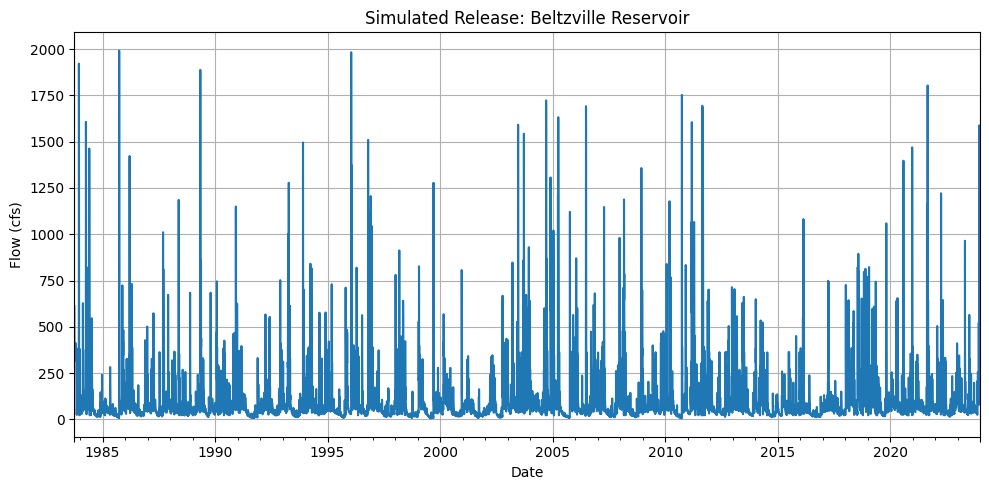

In [10]:
# Plot for a specific reservoir (e.g., 'beltzvilleCombined')
df_reservoir_downstream_gage["beltzvilleCombined"].plot(
    figsize=(10, 5),
    title="Simulated Release: Beltzville Reservoir"
)
plt.ylabel("Flow (cfs)")
plt.xlabel("Date")
plt.grid(True)
plt.tight_layout()
plt.show()


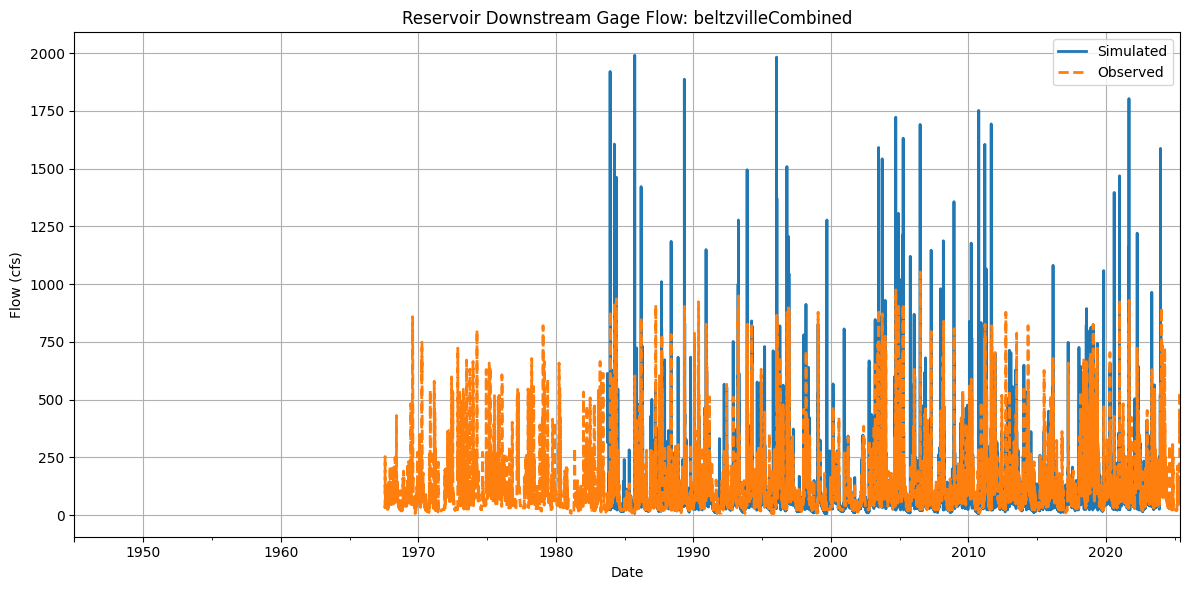

In [11]:
reservoir = "beltzvilleCombined"

plt.figure(figsize=(12, 6))

# Plot simulated release
df_reservoir_downstream_gage[reservoir].plot(label="Simulated", linewidth=2)

# Plot observed release
if reservoir in df_obs_reservoir_downstream_gage.columns:
    df_obs_reservoir_downstream_gage[reservoir].plot(label="Observed", linewidth=2, linestyle="--")
else:
    print(f"Observed data for {reservoir} not found in df_obs_reservoir_downstream_gage")

plt.title(f"Reservoir Downstream Gage Flow: {reservoir}")
plt.ylabel("Flow (cfs)")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
